## Tracking Data

First lets create a function for extracting all the videoTimestamp from all the shots given a match

In [1]:
import json

def extract_video_timestamps_from_shot_file(filepath):

    file_key = filepath.split("/")[-1].replace(".json", "")

    with open(filepath, 'r') as f:
        data = json.load(f)

    timestamps = [event['videoTimestamp'] for event in data if 'videoTimestamp' in event]

    return {file_key: timestamps}


In [2]:
df = extract_video_timestamps_from_shot_file("shot_pack/shots/644507.json")
df

{'644507': ['394.419335',
  '504.904709',
  '590.015496',
  '685.013836',
  '1177.727182',
  '1279.560962',
  '1510.875063',
  '2090.917203',
  '2344.396955',
  '2460.344738',
  '2788.209796',
  '2849.860245',
  '2907.556667',
  '3474.098645',
  '3727.147296',
  '3728.614645',
  '4227.847976',
  '4345.074861',
  '4357.240709',
  '4539.47338',
  '4541.568165',
  '5009.651231',
  '5011.346379',
  '5122.164576',
  '5452.536857',
  '5533.427781']}

Let's also extract the assists videoTimestamp

In [3]:
def extract_assist_info_video_timestamps(filepath):
    file_key = filepath.split("/")[-1].replace(".json", "")
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    timestamps = [
        event['assist_info']['videoTimestamp']
        for event in data
        if event.get('assist_info') and 'videoTimestamp' in event['assist_info']
    ]

    return {file_key: timestamps}


In [4]:
df2 = extract_assist_info_video_timestamps("shot_pack/shots/644507.json")
df2

{'644507': ['392.154206',
  '498.810584',
  '589.109165',
  '676.770239',
  '1176.908849',
  '1278.425758',
  '1510.501844',
  '2088.648279',
  '2342.922265',
  '2458.617965',
  '2847.217446',
  '2905.588464',
  '3472.471286',
  '3722.439072',
  '4225.497118',
  '4343.089214',
  '4356.258991',
  '4536.421677',
  '5008.863938',
  '5008.863938',
  '5121.166837',
  '5451.42945',
  '5531.052243']}

Create a function that gets all frames from tracking data that have the closest videotimestamp from the shots

In [5]:
import json

def get_closest_tracking_frames_for_shots(shot_file, tracking_file):
    with open(shot_file, 'r') as sf:
        shot_data = json.load(sf)
    video_timestamps = [ str(event['videoTimestamp']) for event in shot_data 
    if 'videoTimestamp' in event and event.get('type', {}).get('primary') == 'shot']


    closest_frames = {}
    min_differences = {ts: float('inf') for ts in video_timestamps}


    with open(tracking_file, 'r') as tf:
        for line in tf:
            try:
                frame = json.loads(line)
                
                ts = frame.get('videoTimestamp') or frame.get('Videotimestamp')
                if ts is None:
                    continue
          
                for shot_ts in video_timestamps:
                    diff = abs(ts - float(shot_ts))
                    if diff < min_differences[shot_ts]:
                        min_differences[shot_ts] = diff
                        closest_frames[shot_ts] = frame
            except json.JSONDecodeError:
                continue  

    return closest_frames


And create a function to itarate from all the files

In [6]:
import os

def get_all_shot_tracking_matches(shots_dir, tracking_dir):

    all_matches = {}
    processed_count = 0

    for filename in os.listdir(shots_dir):
        if filename.endswith('.json'):
            match_id = filename.replace('.json', '')
            shot_path = os.path.join(shots_dir, f"{match_id}.json")
            tracking_path = os.path.join(tracking_dir, f"{match_id}_tracking_data.jsonl")

            if os.path.exists(tracking_path):
                result = get_closest_tracking_frames_for_shots(shot_path, tracking_path)
                all_matches[match_id] = result
                processed_count += 1

                if processed_count % 10 == 0:
                    print(f"Processed {processed_count} matches so far...")
            else:
                print(f"Tracking file missing for {match_id}")

    print(f" Total matches processed: {processed_count}")
    return all_matches


In [8]:
all_data = get_all_shot_tracking_matches("shot_pack/shots", "shot_pack/jsonls")

Processed 10 matches so far...
Processed 20 matches so far...
Processed 30 matches so far...
Processed 40 matches so far...
Processed 50 matches so far...
Processed 60 matches so far...
Processed 70 matches so far...
Processed 80 matches so far...
Processed 90 matches so far...
Processed 100 matches so far...
Processed 110 matches so far...
Processed 120 matches so far...
Processed 130 matches so far...
Processed 140 matches so far...
Processed 150 matches so far...
Processed 160 matches so far...
Processed 170 matches so far...
Processed 180 matches so far...
Processed 190 matches so far...
Processed 200 matches so far...
Processed 210 matches so far...
Processed 220 matches so far...
Processed 230 matches so far...
Processed 240 matches so far...
Processed 250 matches so far...
 Total matches processed: 258


In [9]:
all_data["644507"]["394.419335"]

{'data': {'37': [{'x': 63.87, 'y': 45.01, 'vis': False, 'id': 1553280},
   {'x': 6.91, 'y': 25.95, 'vis': False, 'id': 1298177},
   {'x': 10.27, 'y': 18.31, 'vis': False, 'id': 1172505},
   {'x': 29.12, 'y': 12.97, 'vis': True, 'id': 1171229},
   {'x': 18.8, 'y': 30.58, 'vis': True, 'id': 1159205},
   {'x': 31.39, 'y': 40.51, 'vis': False, 'id': 1647671},
   {'x': 37.71, 'y': 22.21, 'vis': False, 'id': 202712},
   {'x': 91.57, 'y': 34.32, 'vis': False, 'id': 1704166},
   {'x': 23.96, 'y': 38.77, 'vis': True, 'id': 1219821},
   {'x': 13.57, 'y': 39.43, 'vis': True, 'id': 1155314},
   {'x': 33.71, 'y': 25.27, 'vis': False, 'id': 753917}],
  '61792': [{'x': 38.35, 'y': 35.31, 'vis': False, 'id': 1159681},
   {'x': 29.6, 'y': 25.8, 'vis': True, 'id': 318471},
   {'x': 38.44, 'y': 25.71, 'vis': False, 'id': 1155884},
   {'x': 12.4, 'y': 34.92, 'vis': True, 'id': 1263292},
   {'x': 49.79, 'y': 9.6, 'vis': False, 'id': 1218371},
   {'x': 31.93, 'y': 43.77, 'vis': False, 'id': 1209052},
   {'x

### VISUALIZATIONS

In [10]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def plot_with_mplsoccer(tracking_frame):

    team_ids = list(tracking_frame['data'].keys())
    if len(team_ids) != 2:
        raise ValueError("Expected exactly 2 teams in the frame 'data' field.")

    team0_id, team1_id = team_ids
    team0 = tracking_frame['data'][team0_id]
    team1 = tracking_frame['data'][team1_id]
    ball = tracking_frame['ball']

    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='grass', line_color='white')
    fig, ax = pitch.draw(figsize=(12, 8))

    pitch.scatter([p['x'] for p in team0], [p['y'] for p in team0], ax=ax,
                  color='blue', label=f'Team {team0_id}', s=100, edgecolors='black')
    pitch.scatter([p['x'] for p in team1], [p['y'] for p in team1], ax=ax,
                  color='red', label=f'Team {team1_id}', s=100, edgecolors='black')
    pitch.scatter(ball[0], ball[1], ax=ax,
                  color='white', edgecolors='black', s=200, label='Ball')

    ax.legend(loc='upper right')
    ax.set_title("Player Positions (Shot Frame)", fontsize=16)
    plt.show()


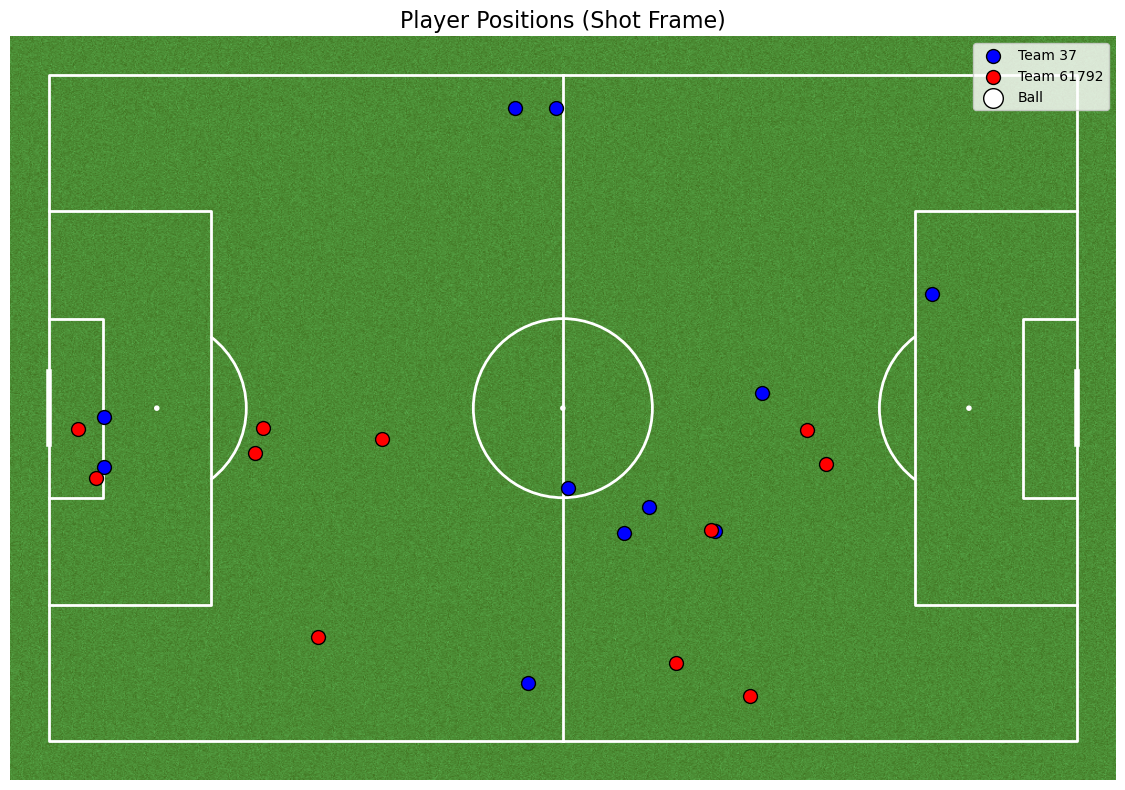

In [11]:
plot_with_mplsoccer(all_data["644507"]["1279.560962"])

In [13]:
all_data.keys()

dict_keys(['670964', '662723', '644580', '644646', '666367', '666388', '644596', '666371', '644650', '662735', '644607', '644555', '644806', '662719', '652706', '644797', '644810', '644543', '672955', '666384', '644563', '666392', '644575', '646548', '666404', '662739', '670138', '644670', '644559', '670143', '662715', '670952', '644631', '644666', '644667', '673955', '644630', '670953', '673369', '662714', '644626', '670142', '644671', '670139', '662738', '644574', '666405', '644827', '666393', '644562', '666385', '644796', '673373', '662718', '644738', '644554', '662734', '644606', '666370', '644651', '644597', '644578', '644647', '666389', '644581', '662722', '672958', '662729', '666382', '644565', '666402', '644573', '644524', '644676', '662713', '644621', '670954', '644637', '644660', '644549', '644494', '670962', '644617', '662725', '644586', '666361', '644640', '644590', '644656', '666377', '666398', '662733', '644800', '644553', '652700', '662709', '644545', '644682', '644817',

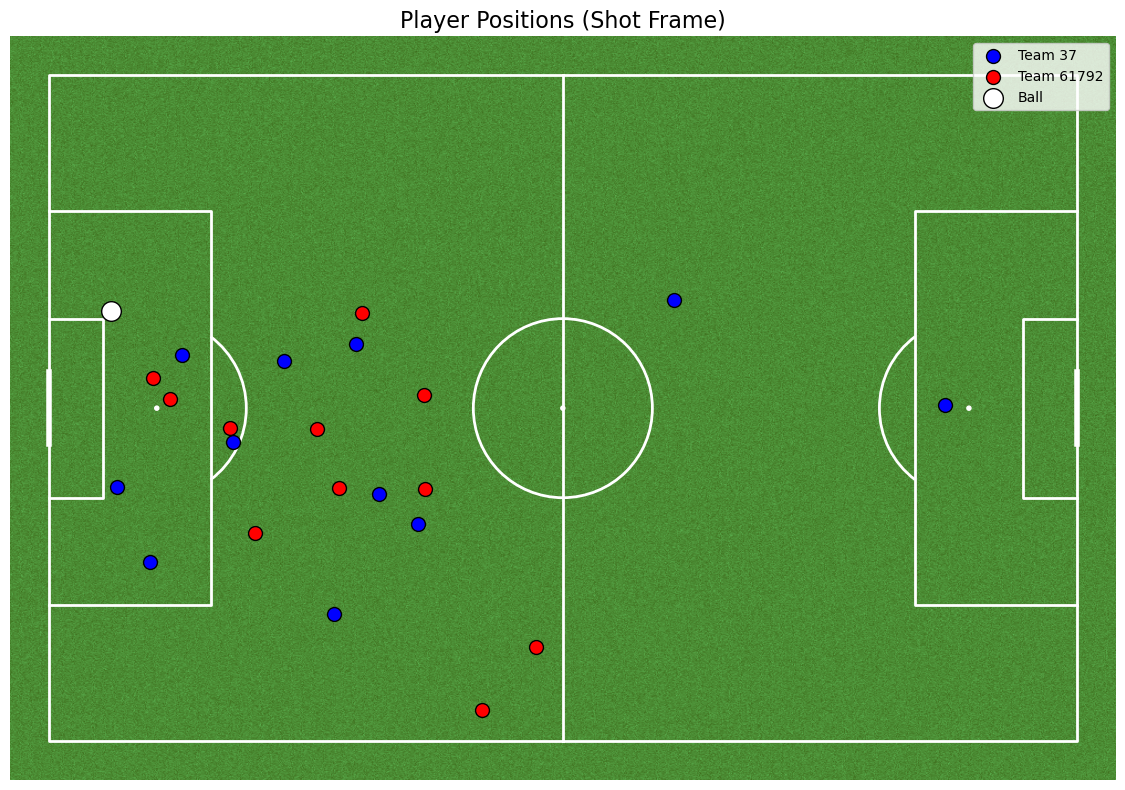

In [31]:
plot_with_mplsoccer(all_data["644507"]["394.419335"])

In [ ]:
# play with delay +-5 s

In [16]:
all_data["644507"]["394.419335"]

{'data': {'37': [{'x': 63.87, 'y': 45.01, 'vis': False, 'id': 1553280},
   {'x': 6.91, 'y': 25.95, 'vis': False, 'id': 1298177},
   {'x': 10.27, 'y': 18.31, 'vis': False, 'id': 1172505},
   {'x': 29.12, 'y': 12.97, 'vis': True, 'id': 1171229},
   {'x': 18.8, 'y': 30.58, 'vis': True, 'id': 1159205},
   {'x': 31.39, 'y': 40.51, 'vis': False, 'id': 1647671},
   {'x': 37.71, 'y': 22.21, 'vis': False, 'id': 202712},
   {'x': 91.57, 'y': 34.32, 'vis': False, 'id': 1704166},
   {'x': 23.96, 'y': 38.77, 'vis': True, 'id': 1219821},
   {'x': 13.57, 'y': 39.43, 'vis': True, 'id': 1155314},
   {'x': 33.71, 'y': 25.27, 'vis': False, 'id': 753917}],
  '61792': [{'x': 38.35, 'y': 35.31, 'vis': False, 'id': 1159681},
   {'x': 29.6, 'y': 25.8, 'vis': True, 'id': 318471},
   {'x': 38.44, 'y': 25.71, 'vis': False, 'id': 1155884},
   {'x': 12.4, 'y': 34.92, 'vis': True, 'id': 1263292},
   {'x': 49.79, 'y': 9.6, 'vis': False, 'id': 1218371},
   {'x': 31.93, 'y': 43.77, 'vis': False, 'id': 1209052},
   {'x